In [ ]:
!pip install spacy
!python -m spacy download en_core_web_sm

In [123]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from google.colab import files
import spacy
nlp = spacy.load("en_core_web_sm")
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Loading the dataset

In [2]:
uploaded = files.upload()

Saving train.csv to train.csv


In [3]:
df= pd.read_csv('train.csv')
df.head()

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [4]:
df.describe()

,toxic,severe_toxic,obscene,threat,insult,identity_hate
count,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000,159571.000000
mean,0.095844,0.009996,0.052948,0.002996,0.049364,0.008805
std,0.294379,0.099477,0.223931,0.054650,0.216627,0.093420
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   id             159571 non-null  object
 1   comment_text   159571 non-null  object
 2   toxic          159571 non-null  int64 
 3   severe_toxic   159571 non-null  int64 
 4   obscene        159571 non-null  int64 
 5   threat         159571 non-null  int64 
 6   insult         159571 non-null  int64 
 7   identity_hate  159571 non-null  int64 
dtypes: int64(6), object(2)
memory usage: 9.7+ MB


check for null values

In [6]:
df.isnull().sum()

,0
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


In [7]:
len(df)

159571

# Exploratory Data Analysis

In [8]:
x=df.iloc[:,2:].sum()
rowsums = df.iloc[:, 2:].sum(axis=1)
rowsums

,0
0,0
1,0
2,0
3,0
4,0
...,...
159566,0
159567,0
159568,0
159569,0


In [9]:
no_label_count=0

for i,count in rowsums.items():
  if count==0:
    no_label_count+=1
print("Total Comments", len(df))
print("Total Comments with no labels", no_label_count)
print('Total labels:',x.sum())

Total Comments 159571
Total Comments with no labels 143346
Total labels: 35098


Total Comments distribution

<Axes: title={'center': 'Label Counts'}, xlabel='Label', ylabel='Count'>

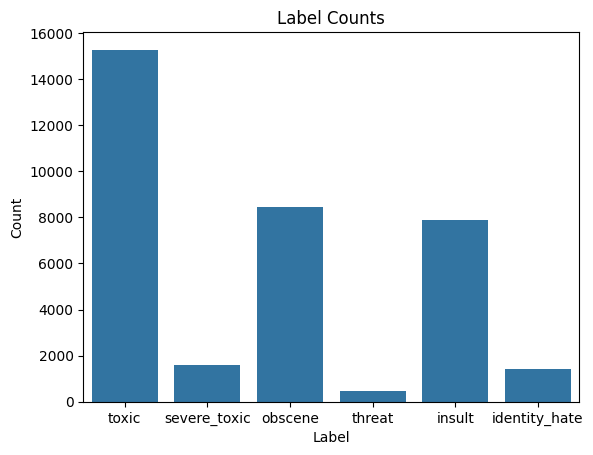

In [10]:
category = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
value = x.values
plt.title('Label Counts')
plt.ylabel('Count')
plt.xlabel('Label')
sns.barplot(x=category, y=value)

Frequency of comments that are not labeled

<Axes: title={'center': 'Labels per Comment'}, xlabel='No of Labels', ylabel='No of occurances'>

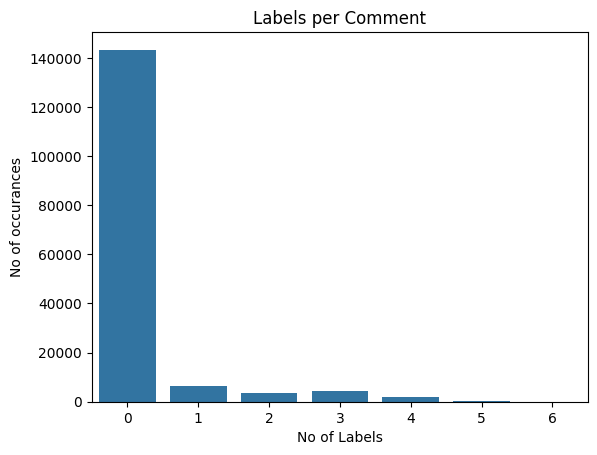

In [11]:
label_counts = rowsums.value_counts()
plt.title('Labels per Comment')
plt.ylabel('No of occurances')
plt.xlabel('No of Labels')
sns.barplot(x=label_counts.index, y=label_counts.values)

# Data Preprocessing

In [12]:
df = df.drop(columns=['id'], axis=1)
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [13]:
lemmatizer = WordNetLemmatizer()
def remove_stopwords_fast(text, stopwords_set):
    return " ".join([w for w in text.split() if w not in stopwords_set])

def clean_text(text):
  text = text.lower()
  #remove urls
  text = re.sub(r"http\S+|www\S+|https\S+", '',text)
  #remove HTML tags
  text = re.sub(r"<.*?>",'',text)
  # Expand words completelely
  exapansion_mapping = {
      "can't": "cannot",
      "cause": "because",
      "what's":"what is",
      "n't": " not",
      "'re": " are",
      "'s": " is",
      "'ve": " have",
      "'ll": " will",
      "'d": " would",
      "i'm": "i am",
      "it's": "it is",
      "'scuse": " excuse" ,
      "cuz": "because",
      "coz": "because",
      "bcuz": "because",
      "bcoz": "because",
      "cus": "because"

  }
  for i,r in exapansion_mapping.items():
    text = re.sub(i,r,text)
  #remove emails
  text = re.sub(r'\S*@\S*\s?', ' ', text)
  #remove @mentions
  text = re.sub(r'@\w+',' ',text)
  # remove hastags
  text = re.sub(r'#(\w+)',r'\1', text)
  # remove numbers
  text = re.sub(r'\d+', ' ', text)
  # Remove non-alphanumeric characters
  text = re.sub(r'[^a-zA-Z\s]', ' ', text)
  # Collapse multiple spaces
  text = re.sub(r'\s+', ' ', text).strip()
  return text
# Stemming
def lemmatize_text(text):
    return " ".join([lemmatizer.lemmatize(lemmatizer.lemmatize(word, pos='v'), pos='n')
                     for word in text.split()])

nltk.download('stopwords', quiet=True)
STOP_WORDS = set(stopwords.words('english'))


In [14]:
df['comment_text'] = df['comment_text'].apply(clean_text)
df['comment_text'] = df['comment_text'].apply(lambda x: remove_stopwords_fast(x, STOP_WORDS))
df['comment_text'] = df['comment_text'].apply(lemmatize_text)
df.head()

,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,explanation edit make username hardcore metall...,0,0,0,0,0,0
1,aww match background colour seemingly stick th...,0,0,0,0,0,0
2,hey man really try edit war guy constantly rem...,0,0,0,0,0,0
3,cannot make real suggestion improvement wonder...,0,0,0,0,0,0
4,sir hero chance remember page,0,0,0,0,0,0


In [15]:
with nlp.select_pipes(disable=["parser"]):
    docs = list(nlp.pipe(df['comment_text'], batch_size=300))
noun_counts = []
verb_counts = []
adj_counts = []
person_ents = []
group_ents = []

for doc in docs:
    # POS counts
    noun_counts.append(sum(1 for token in doc if token.pos_ == "NOUN"))
    verb_counts.append(sum(1 for token in doc if token.pos_ == "VERB"))
    adj_counts.append(sum(1 for token in doc if token.pos_ == "ADJ"))

    # NER counts
    person_ents.append(sum(1 for ent in doc.ents if ent.label_ == "PERSON"))
    group_ents.append(sum(1 for ent in doc.ents if ent.label_ in ["ORG", "NORP"]))

df['noun_count'] = noun_counts
df['verb_count'] = verb_counts
df['adj_count'] = adj_counts
df['person_ents'] = person_ents
df['group_ents'] = group_ents


In [16]:
print(df[['comment_text','noun_count','verb_count','adj_count','person_ents','group_ents']].head(10))
print(df[['noun_count','verb_count','adj_count','person_ents','group_ents']].describe())


                                        comment_text  noun_count  verb_count  \
0  explanation edit make username hardcore metall...           8           2   
1  aww match background colour seemingly stick th...           2           2   
2  hey man really try edit war guy constantly rem...          12           3   
3  cannot make real suggestion improvement wonder...          23           8   
4                      sir hero chance remember page           1           1   
5             congratulation well use tool well talk           2           2   
6                        cocksucker piss around work           2           1   
7  vandalism matt shirvington article revert plea...           1           1   
8  sorry word nonsense offensive anyway intend wr...          17           6   
9               alignment subject contrary dulithgow           4           0   

   adj_count  person_ents  group_ents  
0          0            0           0  
1          0            0           1  

In [17]:
# All caps
df['all_caps'] = df['comment_text'].apply(lambda x: int(any(c.isupper() for c in x)))

# Repeated characters
df['repeated_chars'] = df['comment_text'].apply(lambda x: int(bool(re.search(r'(.)\1{2,}', x))))

# Exclamation marks
df['exclamations'] = df['comment_text'].apply(lambda x: x.count('!'))


In [18]:
df['binary_toxic'] = df[['toxic','severe_toxic','obscene','insult','threat','identity_hate']].max(axis=1)

In [19]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X = tfidf.fit_transform(df['comment_text'])

In [20]:
dense_matrix = X[:5].toarray()
print("TF-IDF matrix for first 5 comments:")
print(dense_matrix)


TF-IDF matrix for first 5 comments:
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [21]:
# combining all features
numeric_features = df[['noun_count','verb_count','adj_count','person_ents','group_ents','all_caps','repeated_chars','exclamations']].values
X_numeric = hstack([X, numeric_features])
y = df['binary_toxic']

/tmp/ipython-input-1093061619.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


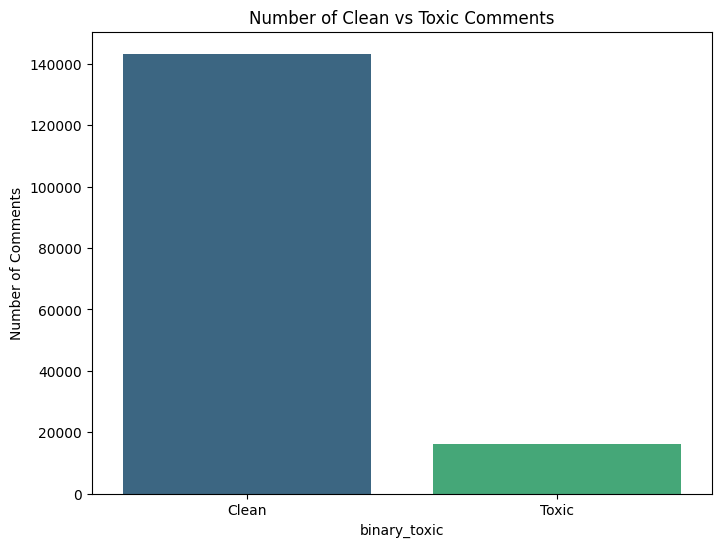

In [22]:
counts = df['binary_toxic'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=counts.index, y=counts.values, palette='viridis')
plt.xticks([0,1], ['Clean','Toxic'])
plt.ylabel('Number of Comments')
plt.title('Number of Clean vs Toxic Comments')
plt.show()

# Evaluation for Binary classification

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)


Logistics Regression

In [25]:
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     28671
           1       0.92      0.65      0.76      3244

    accuracy                           0.96     31915
   macro avg       0.94      0.82      0.87     31915
weighted avg       0.96      0.96      0.96     31915



Naive Bayes

In [27]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train, y_train)
y_pred_nb = nb_clf.predict(X_test)

In [28]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97     28671
           1       0.83      0.56      0.67      3244

    accuracy                           0.94     31915
   macro avg       0.89      0.77      0.82     31915
weighted avg       0.94      0.94      0.94     31915



# Multi-label Classification

In [56]:
gender_keywords = [
    "man", "woman", "male", "female", "girl", "boy", "mother", "father",
    "she", "he", "her", "him"
]

race_keywords = [
    "white", "black", "asian", "indian", "latino", "hispanic",
    "african", "european", "arab", "mexican",'niggers'
]

orientation_keywords = [
    "gay", "lesbian", "lgbt", "trans", "transgender", "queer", "bisexual"
]


In [73]:
def contains_keyword(cleaned_text, keyword_list):
    return any(word in cleaned_text.split() for word in keyword_list)

In [74]:
df["gender_toxic"] = df["comment_text"].apply(lambda x: contains_keyword(x, gender_keywords))
df["race_toxic"] = df["comment_text"].apply(lambda x: contains_keyword(x, race_keywords))
df["orientation_toxic"] = df["comment_text"].apply(lambda x: contains_keyword(x, orientation_keywords))

In [75]:
df["pred_binary"] = clf.predict(X_numeric)
df["true_binary"] = df["binary_toxic"]

In [76]:
def fairness_scores(df, group_col):
    subgroup = df[df[group_col] == True]
    TP = sum((subgroup["pred_binary"] == 1) & (subgroup["true_binary"] == 1))
    TN = sum((subgroup["pred_binary"] == 0) & (subgroup["true_binary"] == 0))
    FP = sum((subgroup["pred_binary"] == 1) & (subgroup["true_binary"] == 0))
    FN = sum((subgroup["pred_binary"] == 0) & (subgroup["true_binary"] == 1))
    pos_rate = (TP + FP) / len(subgroup)
    tpr = TP / (TP + FN + 1e-9)
    fpr = FP / (FP + TN + 1e-9)
    fnr = FN / (TP + FN + 1e-9)
    return {
        "Positive Rate": round(pos_rate, 3),
        "TPR": round(tpr, 3),
        "FPR": round(fpr, 3),
        "FNR": round(fnr, 3),
        "Samples": len(subgroup)
    }


In [77]:
fair_gender = fairness_scores(df, "gender_toxic")
fair_race = fairness_scores(df, "race_toxic")
fair_orient = fairness_scores(df, "orientation_toxic")
print("Gender Fairness:", fair_gender)
print("Race Fairness:", fair_race)
print("Orientation Fairness:", fair_orient)


Gender Fairness: {'Positive Rate': 0.162, 'TPR': 0.688, 'FPR': 0.019, 'FNR': 0.312, 'Samples': 6266}
Race Fairness: {'Positive Rate': 0.077, 'TPR': 0.581, 'FPR': 0.01, 'FNR': 0.419, 'Samples': 4342}
Orientation Fairness: {'Positive Rate': 0.482, 'TPR': 0.816, 'FPR': 0.107, 'FNR': 0.184, 'Samples': 1163}


In [78]:
gender_comments = df[df["gender_toxic"] == True][["comment_text"]].head(20)
print(gender_comments)

                                          comment_text
2    hey man really try edit war guy constantly rem...
11                 bbq man let disbecauses maybe phone
14   oh girl start argument stick nose belong belie...
27   yes bebecause mother child case michael jackso...
35   make straw man argument never claim wouldonohu...
36   mainland asia include lower basin china yangtz...
43                           fuck filthy mother as dry
49   jmabel regard predominant scholary consensus a...
58   band page deletion think go delete comment pos...
61   bisexual like homosexual heterosexual define s...
108  vandalize fun man sense humor think vandalize ...
126  ahh hello witzeman symbol character greek cyri...
172  friesers opinion simple guess kursk turn point...
181                      stupid fuck mother cunt stink
213  please see ref article mention wikipedia young...
214  randroide answer next step guy see take step w...
238   u r fuck u gay boy u r smelly fuck ur mum poopie
244  name 

In [79]:
race_comments = df[df["race_toxic"] == True][["comment_text"]].head(20)
print(race_comments)


                                          comment_text
36   mainland asia include lower basin china yangtz...
42   gay antisemmitian archangel white tiger meow g...
63   christian arab hi could please stop enforce ca...
104  page shoudld important character reoccur void ...
153  pd see apart article coat arm sahrawi arab dem...
160  attribute classify personality invitation inpu...
167  hi hi good day deepest apology make change mak...
179  reply loser un define vietnam part southeast a...
183  new userbox tabtab id tabtab id c white tabtab...
234  add information mayor de blasio announce decis...
260  thank copy edit omg read professional apprecia...
366  paula white joel osteen marble cat others imag...
377  wp blp violation remove another revert place d...
505  meet local vietnam tv series factual documenta...
528  afican union site vandalism dear bracketbot wr...
596  macedonian slavic bulgarian possibly note repu...
645  deletion minority post nice try try silence sl...
661  wikip

In [80]:
orientation_comments = df[df["orientation_toxic"] == True][["comment_text"]].head(20)
print(orientation_comments)


                                           comment_text
42    gay antisemmitian archangel white tiger meow g...
61    bisexual like homosexual heterosexual define s...
183   new userbox tabtab id tabtab id c white tabtab...
198   homosexual intent legitimize behavior therefor...
238    u r fuck u gay boy u r smelly fuck ur mum poopie
425   quote hoppe first detail kinsella important po...
429   gay existence cdvf proof sad twat also ugly wi...
542   hi fracophonie thank take time write long mess...
545                                     jeff garcia gay
699   regard loyalmoonie lgbt category look editor s...
887   gay motherfucker know live go sand face go bea...
928   opinion proof anti newsom whether support gay ...
1017  would first time bitch fuck find live sodomize...
1161  someone explain criticism take criticism secti...
1253               homosexual marriage totally gay well
1271  writer paragraph mean rude statement van johns...
1297  hi see blank gay article administrator act

In [81]:
tox_cols = ["toxic","severe_toxic","obscene","threat","insult","identity_hate"]
gender_counts = df[df["gender_toxic"] == True][tox_cols].sum()
race_counts = df[df["race_toxic"] == True][tox_cols].sum()
orientation_counts = df[df["orientation_toxic"] == True][tox_cols].sum()
tox_summary = pd.DataFrame({
    "Gender": gender_counts,
    "Race": race_counts,
    "Orientation": orientation_counts
})
print(tox_summary)


               Gender  Race  Orientation
toxic            1247   462          587
severe_toxic      155    39           87
obscene           720   218          302
threat             38    16           21
insult            679   233          341
identity_hate     169   162          300


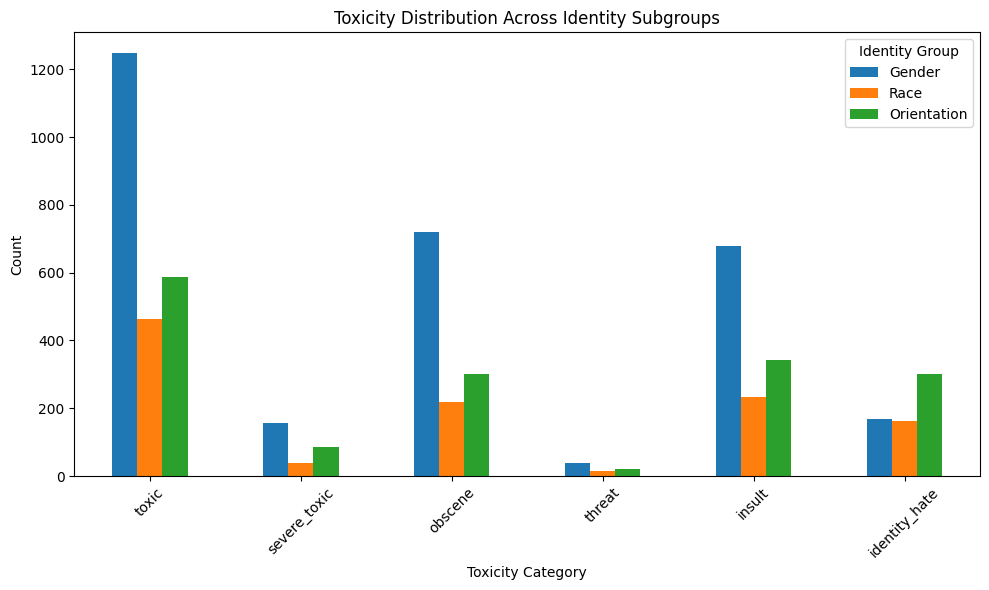

In [82]:
tox_summary.plot(kind="bar", figsize=(10,6))
plt.title("Toxicity Distribution Across Identity Subgroups")
plt.xlabel("Toxicity Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Identity Group")
plt.tight_layout()
plt.show()


# Evaluation for Multi-label classification

In [113]:
y = df[['toxic','severe_toxic','obscene','threat','insult','identity_hate',
        'gender_toxic','race_toxic','orientation_toxic']]
df[y.columns] = df[y.columns].astype(int)

Logistic regression

In [114]:
X_train_combined, X_test_combined, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)
model = OneVsRestClassifier(LogisticRegression(max_iter=1000))
model.fit(X_train_combined, y_train)

OneVsRestClassifier(estimator=LogisticRegression(max_iter=1000))

In [115]:
def predict_comment(raw_comment_text):
    cleaned_comment = clean_text(raw_comment_text)
    cleaned_comment = remove_stopwords_fast(cleaned_comment, STOP_WORDS)
    cleaned_comment = lemmatize_text(cleaned_comment)
    vec = tfidf.transform([cleaned_comment])
    doc = nlp(cleaned_comment)
    all_caps_feature = int(any(c.isupper() for c in cleaned_comment))
    repeated_chars_feature = int(bool(re.search(r'(.)\1{2,}', cleaned_comment)))
    exclamations_feature = cleaned_comment.count('!')
    numeric = np.array([
        sum(1 for t in doc if t.pos_ == "NOUN"),
        sum(1 for t in doc if t.pos_ == "VERB"),
        sum(1 for t in doc if t.pos_ == "ADJ"),
        sum(1 for ent in doc.ents if ent.label_ == "PERSON"),
        sum(1 for ent in doc.ents if ent.label_ in ["ORG","NORP"]),
        all_caps_feature,
        repeated_chars_feature,
        exclamations_feature
    ]).reshape(1, -1)

    final_features = hstack([vec, numeric])
    pred = model.predict(final_features)[0]
    labels = y.columns.tolist()
    return {labels[i]: pred[i] for i in range(len(labels))}

In [116]:
y_pred = model.predict(X_test_combined)
y_pred_int = y_pred.astype(int)

In [117]:
print(classification_report(y_test.astype(int), y_pred_int, target_names=y.columns))

                   precision    recall  f1-score   support

            toxic       0.90      0.63      0.74      3056
     severe_toxic       0.59      0.27      0.37       321
          obscene       0.91      0.65      0.76      1715
           threat       0.62      0.11      0.18        74
           insult       0.82      0.54      0.65      1614
    identity_hate       0.72      0.18      0.29       294
     gender_toxic       0.99      0.72      0.83      1271
       race_toxic       0.99      0.64      0.77       869
orientation_toxic       0.99      0.57      0.73       230

        micro avg       0.90      0.60      0.72      9444
        macro avg       0.84      0.48      0.59      9444
     weighted avg       0.89      0.60      0.71      9444
      samples avg       0.10      0.09      0.09      9444



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [131]:
label_accuracies = (y_test.values == y_pred_int).mean(axis=0)
print("Logistic Regression - Label-wise Accuracy:\n", dict(zip(y.columns, label_accuracies)))


Logistic Regression - Label-wise Accuracy:
 {'toxic': np.float64(0.9580448065173116), 'severe_toxic': np.float64(0.9907880307065643), 'obscene': np.float64(0.9779100736330879), 'threat': np.float64(0.9977753407488642), 'insult': np.float64(0.9705467648441172), 'identity_hate': np.float64(0.9917906940310199), 'gender_toxic': np.float64(0.9884693717687608), 'race_toxic': np.float64(0.9898167006109979), 'orientation_toxic': np.float64(0.9968980103399655)}


overall accuracy

In [133]:
exact_acc_log = accuracy_score(y_test_int, y_pred_int)
print("Logistic Regression - Exact Match Accuracy:", exact_acc_log)

Logistic Regression - Exact Match Accuracy: 0.8996083346388846


Naive Bayes

In [118]:
model_nb = OneVsRestClassifier(MultinomialNB())
model_nb.fit(X_train_combined[:, :5000], y_train)

OneVsRestClassifier(estimator=MultinomialNB())

In [119]:
y_pred_nb = model_nb.predict(X_test_combined[:, :5000])
y_pred_nb_int = y_pred_nb.astype(int)

In [120]:
print(classification_report(y_test.astype(int), y_pred_nb_int, target_names=y.columns))

                   precision    recall  f1-score   support

            toxic       0.91      0.53      0.67      3056
     severe_toxic       0.47      0.26      0.33       321
          obscene       0.88      0.54      0.67      1715
           threat       0.00      0.00      0.00        74
           insult       0.81      0.47      0.59      1614
    identity_hate       0.41      0.11      0.18       294
     gender_toxic       0.96      0.26      0.41      1271
       race_toxic       0.81      0.28      0.41       869
orientation_toxic       0.71      0.23      0.35       230

        micro avg       0.85      0.43      0.57      9444
        macro avg       0.66      0.30      0.40      9444
     weighted avg       0.84      0.43      0.56      9444
      samples avg       0.06      0.05      0.05      9444



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [134]:
label_acc_nb = (y_test.values == y_pred_nb_int).mean(axis=0)
print("Naive Bayes - Label-wise Accuracy:\n", dict(zip(y.columns, label_acc_nb)))

Naive Bayes - Label-wise Accuracy:
 {'toxic': np.float64(0.9501801660661131), 'severe_toxic': np.float64(0.9896600344665518), 'obscene': np.float64(0.9713300955663481), 'threat': np.float64(0.9972113426288579), 'insult': np.float64(0.9674447751840827), 'identity_hate': np.float64(0.9903180322732258), 'gender_toxic': np.float64(0.9701080996396678), 'race_toxic': np.float64(0.9785680714397619), 'orientation_toxic': np.float64(0.9937646874510419)}


Overall Accuracy


In [136]:
exact_acc_nb = accuracy_score(y_test_int, y_pred_nb_int)
print("Naive Bayes - Exact Match Accuracy:", exact_acc_nb)

Naive Bayes - Exact Match Accuracy: 0.8675857747140843


Testing the comments

In [121]:
test = predict_comment("You idiot, go back to your country")
print(test)

{'toxic': np.int64(1), 'severe_toxic': np.int64(0), 'obscene': np.int64(0), 'threat': np.int64(0), 'insult': np.int64(1), 'identity_hate': np.int64(0), 'gender_toxic': np.int64(0), 'race_toxic': np.int64(0), 'orientation_toxic': np.int64(0)}


In [122]:
test = predict_comment("You are an ignorant mexican.")
print(test)

{'toxic': np.int64(1), 'severe_toxic': np.int64(0), 'obscene': np.int64(0), 'threat': np.int64(0), 'insult': np.int64(0), 'identity_hate': np.int64(0), 'gender_toxic': np.int64(0), 'race_toxic': np.int64(1), 'orientation_toxic': np.int64(0)}


In [101]:
test = predict_comment("Black people are inferior.")
print(test)

{'toxic': np.int64(0), 'severe_toxic': np.int64(0), 'obscene': np.int64(0), 'threat': np.int64(0), 'insult': np.int64(0), 'identity_hate': np.int64(0), 'gender_toxic': np.int64(0), 'race_toxic': np.int64(1), 'orientation_toxic': np.int64(0)}


In [102]:
test = predict_comment("I hate this group of people")
print(test)

{'toxic': np.int64(0), 'severe_toxic': np.int64(0), 'obscene': np.int64(0), 'threat': np.int64(0), 'insult': np.int64(0), 'identity_hate': np.int64(0), 'gender_toxic': np.int64(0), 'race_toxic': np.int64(0), 'orientation_toxic': np.int64(0)}


In [103]:
test = predict_comment("No wonder nobody likes you; you're so stupid.")
print(test)

{'toxic': np.int64(1), 'severe_toxic': np.int64(0), 'obscene': np.int64(0), 'threat': np.int64(0), 'insult': np.int64(1), 'identity_hate': np.int64(0), 'gender_toxic': np.int64(0), 'race_toxic': np.int64(0), 'orientation_toxic': np.int64(0)}
